# 📌 Extracción

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Cargar el archivo JSON y aplanar su estructura anidada
with open('TelecomX_Data.json', 'r') as file:
    data = json.load(file)

df = pd.json_normalize(data)
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 🔧 Transformación
## 1. Conoce el conjunto de datos

In [2]:
print("Dimensiones del dataframe:", df.shape)
print("\nInformación general de las columnas:")
df.info()


Dimensiones del dataframe: (7267, 21)

Información general de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7

## 2. Comprobación de incoherencia en los datos

In [3]:
# Verificamos valores nulos
print("Valores nulos por columna:\n", df.isnull().sum())

# Verificamos si hay filas duplicadas exactas
print("\nFilas duplicadas:", df.duplicated().sum())

# Revisamos la columna account.Charges.Total, que figura como 'object' a pesar de ser números
print("\nRegistros con espacios en blanco en account.Charges.Total:", len(df[df['account.Charges.Total'] == ' ']))


Valores nulos por columna:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Filas duplicadas: 0

Registros con espacios en blanco en account.Charges.Total: 11


## 3. Manejo de inconsistencias

In [4]:
# Reemplazamos los espacios vacíos por valores nulos reales (NaN)
df['account.Charges.Total'] = df['account.Charges.Total'].replace([' ', ''], np.nan)

# Convertimos la columna a tipo numérico (float)
df['account.Charges.Total'] = df['account.Charges.Total'].astype(float)

# Eliminamos las filas con valores nulos (son pocas, no afectarán significativamente)
df.dropna(subset=['account.Charges.Total'], inplace=True)

# Limpiamos filas donde el 'Churn' sea un string vacío o irregular
df = df[df['Churn'].isin(['Yes', 'No'])]

df.reset_index(drop=True, inplace=True)
print("Valores nulos tras limpieza:\n", df.isnull().sum())


Valores nulos tras limpieza:
 customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


## 4. Columna de cuentas diarias

In [5]:
# Creamos una columna para calcular el cargo diario aproximado
df['account.Charges.Daily'] = round(df['account.Charges.Monthly'] / 30, 2)
df[['account.Charges.Monthly', 'account.Charges.Daily']].head()


,account.Charges.Monthly,account.Charges.Daily
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


## 5. Estandarización y transformación de datos

In [6]:
# Simplificamos los nombres de las columnas quitando los prefijos
df.columns = [col.split('.')[-1] if '.' in col else col for col in df.columns]

# Renombramos para evitar colisiones y hacerlas más legibles
df.rename(columns={'Monthly': 'MonthlyCharges', 'Total': 'TotalCharges', 'Daily': 'DailyCharges'}, inplace=True)

# Mapeamos la variable objetivo ('Churn') a valores numéricos para análisis de correlación
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Columnas actuales:\n", df.columns.tolist())
df.head()


Columnas actuales:
 ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'DailyCharges', 'Churn_numeric']


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,DailyCharges,Churn_numeric
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1


# 📊 Carga y análisis
## 1. Análisis Descriptivo

In [7]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,DailyCharges,Churn_numeric
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159891,0.265785
std,0.368844,24.545260,30.085974,2266.771362,1.002955,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.610000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,1.187500,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,2.340000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,2.992500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.960000,1.000000


## 2. Distribución de evasión

C:\Users\Surface\AppData\Local\Temp\ipykernel_17536\2177239007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


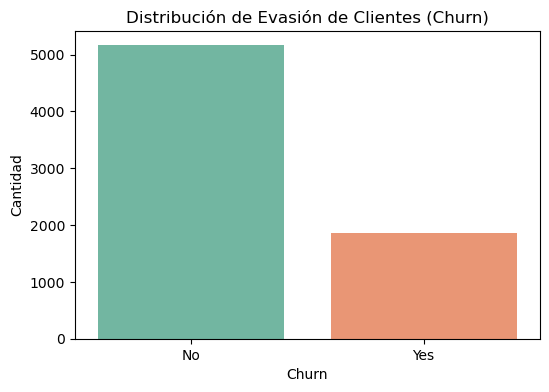

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.ylabel('Cantidad')
plt.show()

# Proporción porcentual
print(df['Churn'].value_counts(normalize=True) * 100)


## 3. Recuento de evasión por variables categóricas

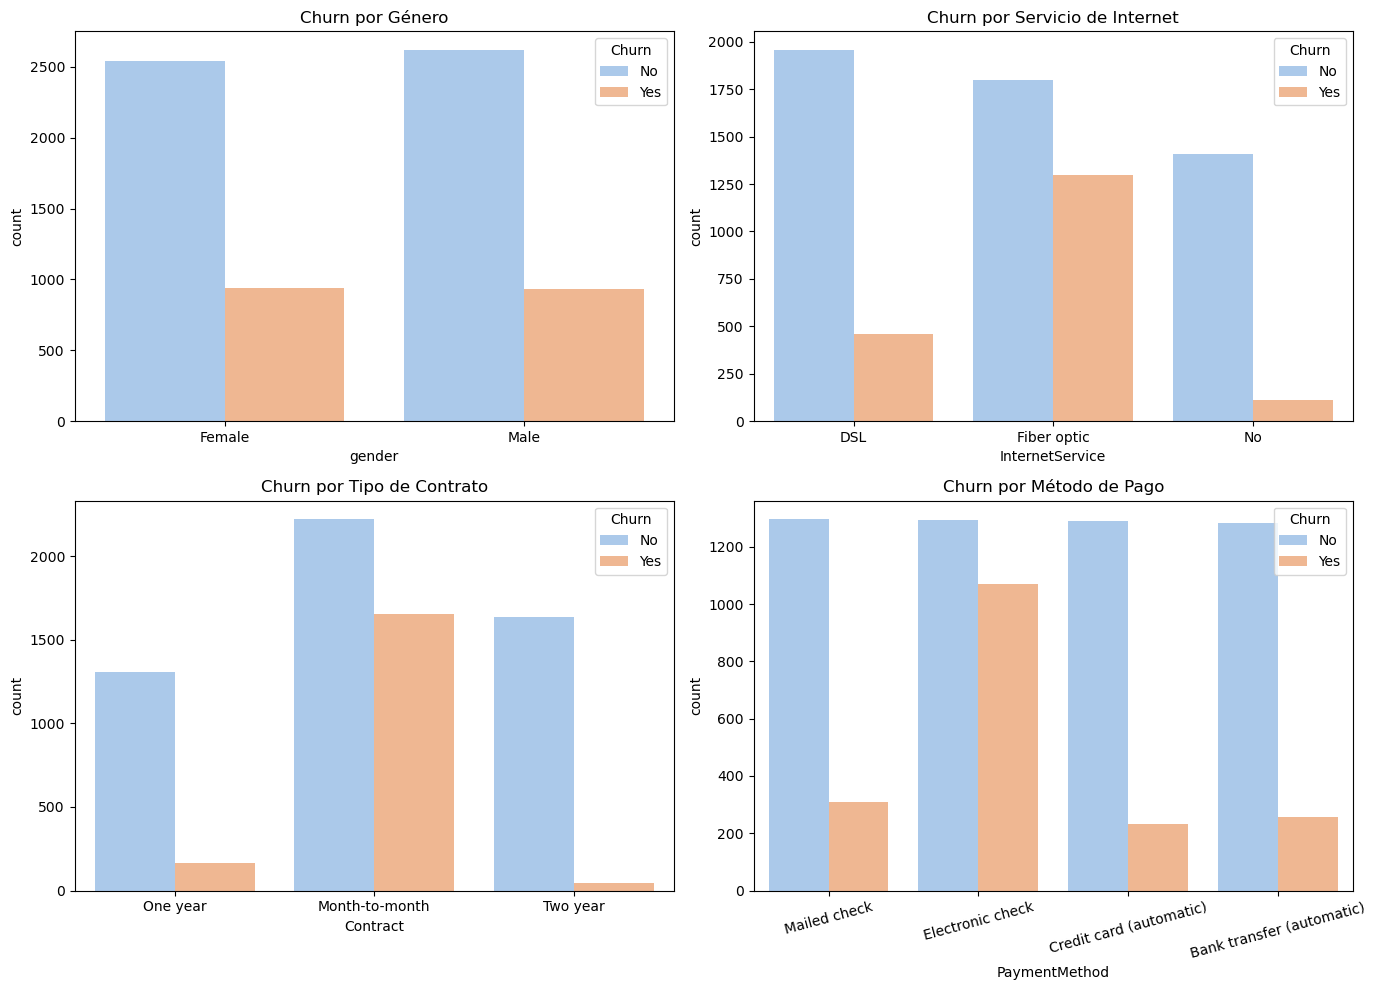

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='gender', hue='Churn', data=df, ax=axes[0,0], palette='pastel')
axes[0,0].set_title('Churn por Género')

sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0,1], palette='pastel')
axes[0,1].set_title('Churn por Servicio de Internet')

sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Churn por Tipo de Contrato')

sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1,1], palette='pastel')
axes[1,1].set_title('Churn por Método de Pago')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## 4. Conteo de evasión por variables numéricas

C:\Users\Surface\AppData\Local\Temp\ipykernel_17536\40092311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='coolwarm')
C:\Users\Surface\AppData\Local\Temp\ipykernel_17536\40092311.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='coolwarm')
C:\Users\Surface\AppData\Local\Temp\ipykernel_17536\40092311.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='coolwarm')


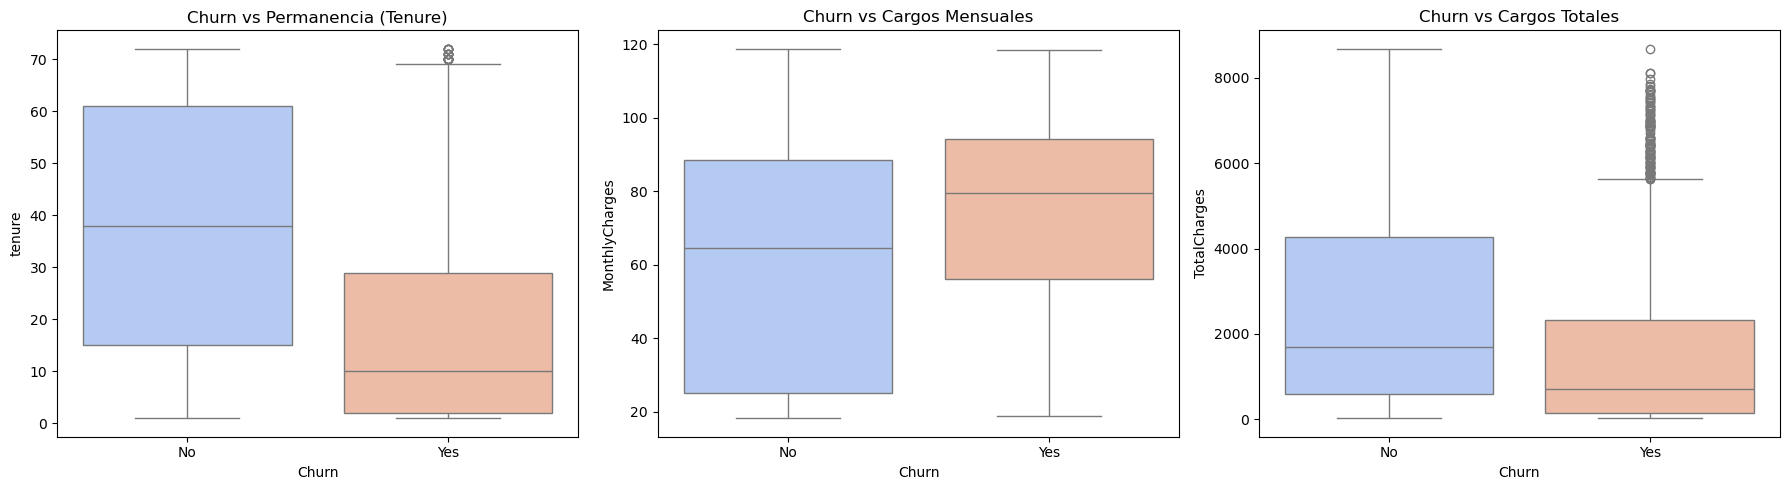

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Churn vs Permanencia (Tenure)')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Churn vs Cargos Mensuales')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Churn vs Cargos Totales')

plt.tight_layout()
plt.show()


# 📝 Informe final

### Insights Principales (Análisis Exploratorio)

Tras limpiar y analizar los datos de Telecom X, identificamos los siguientes patrones de evasión (Churn):

1. **Tipo de Contrato:** Los clientes con contrato de mes a mes (**Month-to-month**) presentan una tasa de cancelación masiva en comparación con contratos de 1 o 2 años.
2. **Servicio de Internet:** Quienes usan fibra óptica (**Fiber optic**) desertan significativamente más que aquellos con ADSL (DSL). Esto sugiere que la fibra óptica podría estar presentando problemas de estabilidad, velocidad, o ser demasiado costosa.
3. **Facturación y Pagos:** El método de pago electrónico (**Electronic check**) concentra el mayor número de cancelaciones.
4. **Cargos y Permanencia:** Los usuarios que abandonan Telecom X tienden a ser clientes nuevos (con bajo `tenure`), y además pagan cuotas mensuales (**MonthlyCharges**) mucho más elevadas que los clientes que deciden quedarse.

**Recomendación:** Enfocar las estrategias de retención en incentivar planes de mayor duración (ej. ofrecer descuentos para migrar a contrato anual), revisar de urgencia la calidad del servicio de Fibra Óptica, y dar atención focalizada a los clientes durante sus primeros meses de servicio, donde la fuga es mayor.

# 🌟 Extra: Análisis de correlación entre variables

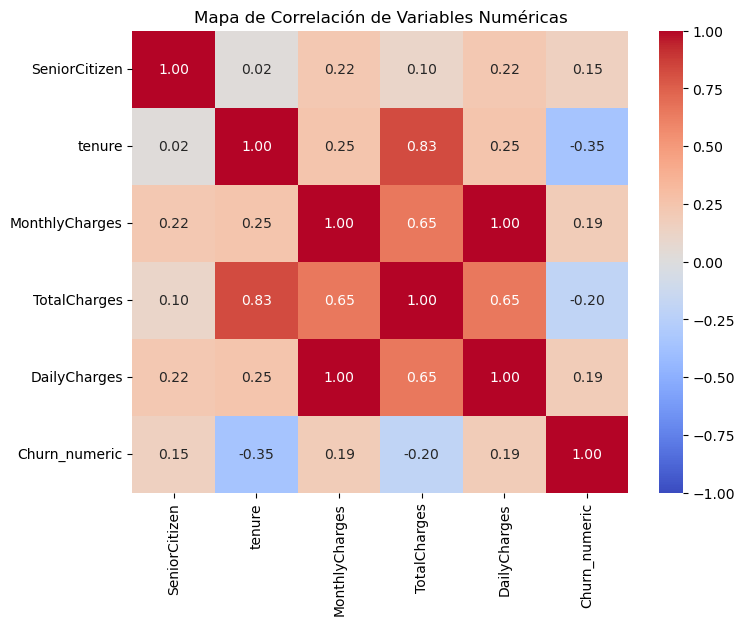

In [11]:
# Seleccionamos las variables numéricas incluyendo el Churn mapeado
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()
